# Bacotypes of Klebsiella 

In [15]:
# Imports
import anndata as ad
import scanpy as sc
import pandas as pd

In [16]:
# Embeddings
embeddings_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/klebsiella_genome_embeddings.pq"
embeddings = pd.read_parquet(embeddings_file, engine="pyarrow")
metadata_file = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/final/metadata_final_curated_slimmed.tsv"
metadata = pd.read_csv(metadata_file, sep="\t")

print("Embeddings shape:", embeddings.shape)
print("Embeddings index (first 5):", embeddings.index[:5])
print("Metadata shape before indexing:", metadata.shape)
print("Metadata columns:", metadata.columns.tolist())

# Set metadata index to Sample column to link with embeddings index (sample_id)
metadata = metadata.set_index('Sample')

print("Metadata index name after set_index:", metadata.index.name)
print("Metadata index (first 5):", metadata.index[:5])

# Align metadata with embeddings index to ensure proper matching
metadata_aligned = metadata.reindex(embeddings.index)

print("Aligned metadata shape:", metadata_aligned.shape)
print("Number of missing metadata rows after alignment:", metadata_aligned.isna().all(axis=1).sum())

# Make an AnnData object with aligned metadata
# All metadata columns will be available in adata.obs for annotation
adata = ad.AnnData(X=embeddings.values, obs=metadata_aligned)

print("AnnData X shape:", adata.X.shape)
print("AnnData obs shape:", adata.obs.shape)

# Add embeddings to the AnnData object
adata.obsm["X_emb"] = embeddings.values

/tmp/ipykernel_68260/2923161086.py:5: DtypeWarning: Columns (20,133,136,138,152,153,154,155,156) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata_file, sep="\t")


Embeddings shape: (3305, 960)
Embeddings index (first 5): Index(['SAMD00055731', 'SAMD00052620', 'SAMD00052614', 'SAMD00055738',
       'SAMD00055758'],
      dtype='object', name='sample_id')
Metadata shape before indexing: (88303, 157)
Metadata columns: ['Sample', 'is_kpsc', 'kpsc_final_list', 'is_refseq', 'is_nctc', 'species', 'species_match', 'Clonal group', 'LINcode', 'Phylogroup', 'Sublineage', 'scgST', 'contig_count', 'N50', 'largest_contig', 'total_size', 'ambiguous_bases', 'QC_warnings', 'ST', 'gapA', 'infB', 'mdh', 'pgi', 'phoE', 'rpoB', 'tonB', 'YbST', 'Yersiniabactin', 'ybtS', 'ybtX', 'ybtQ', 'ybtP', 'ybtA', 'irp2', 'irp1', 'ybtU', 'ybtT', 'ybtE', 'fyuA', 'spurious_ybt_hits', 'CbST', 'Colibactin', 'clbA', 'clbB', 'clbC', 'clbD', 'clbE', 'clbF', 'clbG', 'clbH', 'clbI', 'clbL', 'clbM', 'clbN', 'clbO', 'clbP', 'clbQ', 'spurious_clb_hits', 'AbST', 'Aerobactin', 'iucA', 'iucB', 'iucC', 'iucD', 'iutA', 'spurious_abst_hits', 'SmST', 'Salmochelin', 'iroB', 'iroC', 'iroD', 'iroN', '

In [17]:
# compute neighbors with scanpy
sc.pp.neighbors(adata, use_rep="X_emb")
# compute UMAP
sc.tl.umap(adata)

ST grouping: ST_top
ST16     164
ST147    160
ST11     128
ST231    117
ST15     108
Name: count, dtype: int64


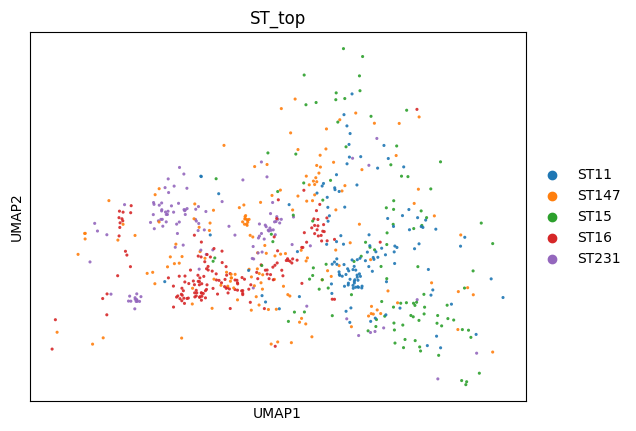

In [18]:
# Create ST grouping: top 5 most frequent STs, rest as 'other'
st_counts = adata.obs['ST'].value_counts()
n_top_st = 5
top_st = st_counts.head(n_top_st).index

# Option to filter out 'other' samples (True) or include them as 'other' category (False)
filter_other = True

if filter_other:
    # Filter to only include top STs
    adata = adata[adata.obs['ST'].isin(top_st)].copy()
    adata.obs['ST_top'] = adata.obs['ST']
else:
    # Keep all samples, mark non-top STs as 'other'
    # Convert to string first to avoid categorical assignment issues
    st_str = adata.obs['ST'].astype(str)
    adata.obs['ST_top'] = st_str.where(st_str.isin([str(st) for st in top_st]), other='other')

adata.obs['ST_top'] = adata.obs['ST_top'].astype('category')

print(f"ST grouping: {adata.obs['ST_top'].value_counts()}")

# UMAP colored by grouped ST (top 5 + 'other' if filter_other=False)
sc.pl.umap(
    adata,
    color='ST_top',
    size=20,
    alpha=0.9,
)

Leiden cluster sizes (top 5 + other): leiden_top
other    245
0        127
1        107
2         74
3         62
4         62
Name: count, dtype: int64


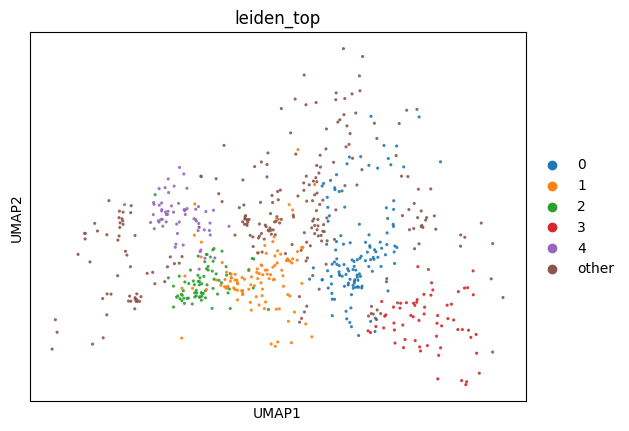

In [21]:
# Leiden clustering with resolution 0.5
sc.tl.leiden(adata, resolution=0.5)

# Group top 5 Leiden clusters, rest as 'other'
n_top_clusters = 5
cluster_sizes = adata.obs['leiden'].value_counts()
top_clusters = cluster_sizes.head(n_top_clusters).index
leiden_str = adata.obs['leiden'].astype(str)
adata.obs['leiden_top'] = leiden_str.where(leiden_str.isin([str(c) for c in top_clusters]), other='other')
adata.obs['leiden_top'] = adata.obs['leiden_top'].astype('category')

print("Leiden cluster sizes (top 5 + other):", adata.obs['leiden_top'].value_counts())

sc.pl.umap(
    adata,
    color='leiden_top',
    size=20,
    alpha=0.9,
)

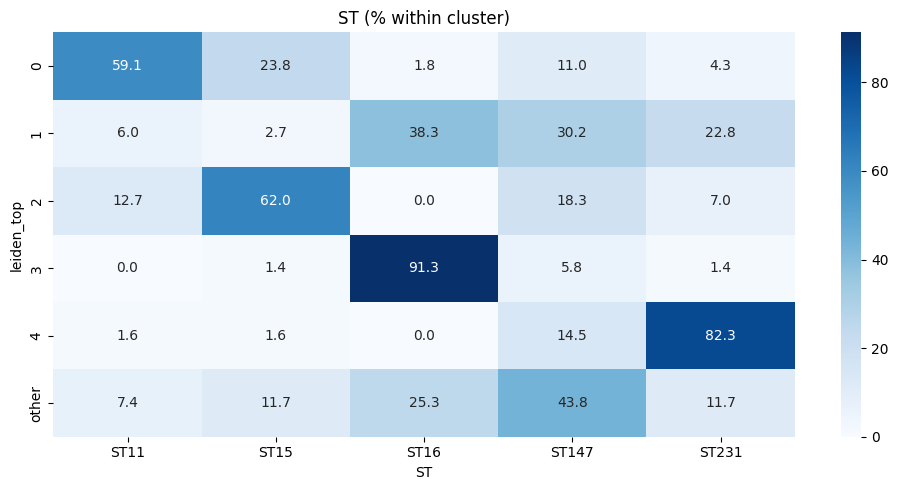

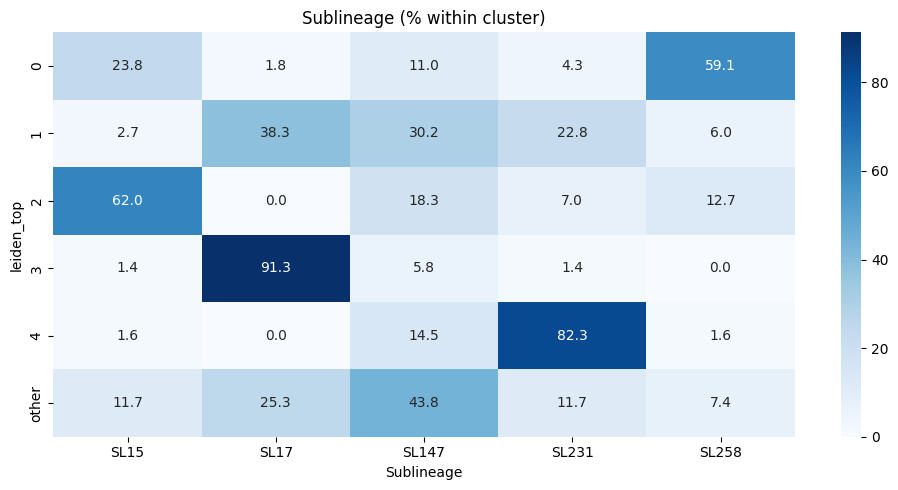

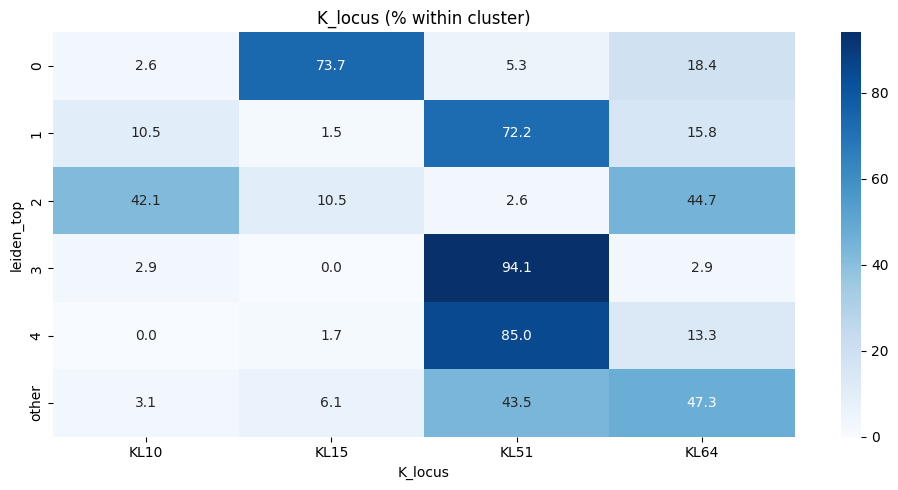

In [20]:
# Heatmaps of variable categories by leiden_top cluster
import matplotlib.pyplot as plt
import seaborn as sns

cross_variables = ['ST', "Sublineage", "K_locus"]
min_total_pct = 5.0  # Only include columns where total % of population > this

for var in cross_variables:
    if var not in adata.obs.columns:
        print(f"Warning: {var} not found in adata.obs.columns, skipping...")
        continue
    
    contingency = pd.crosstab(adata.obs['leiden_top'], adata.obs[var])
    total_pct = contingency.sum(axis=0) / len(adata) * 100
    cols_to_keep = total_pct[total_pct > min_total_pct].index
    contingency = contingency[cols_to_keep]
    
    if len(cols_to_keep) == 0:
        print(f"No {var} categories with total % > {min_total_pct}, skipping.")
        continue
    
    pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
    
    fig, ax = plt.subplots(figsize=(max(10, pct.shape[1] * 0.3), 5))
    sns.heatmap(pct, annot=True, fmt='.1f', cmap='Blues', ax=ax)
    ax.set_title(f'{var} (% within cluster)')
    ax.set_xlabel(var)
    ax.set_ylabel('leiden_top')
    plt.tight_layout()
    plt.show()

